# The Project Design

## 1. Perception Layer (Image Processing)

These components process raw user photos to detect clothing items and extract attributes. Where supported by the platform, models can run in parallel using threads.

### A. Clothing Detection & Segmentation (RF-DETR Segmentation Nano)

**Model:** RF-DETR Segmentation Nano (Instance Segmentation), trained on Fashionpedia (≈50K images with masks).
**Purpose:** Detect garments (top/bottom/shoes), crop them, and provide category + confidence.

#### Input:

A raw photo of a person or a flat-lay clothing image.

#### Output:

A list of detected clothing items (bbox + mask + category + confidence + cropped image).

#### Example:

```txt
Input:
    PIL.Image()  # e.g. (1920x1080)

Output:
    [
        {
            "category_id": 1,         # "Top"
            "confidence": 0.98,
            "bbox": [100, 50, 400, 500],
            "mask": np.ndarray(...),  # optional binary mask
            "image": PIL.Image()      # Cropped Top
        },
        {
            "category_id": 2,         # "Bottom"
            "confidence": 0.94,
            "bbox": [120, 420, 420, 980],
            "mask": np.ndarray(...),
            "image": PIL.Image()
        }
    ]
```

[2026-03-03 20:19:54] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-03-03 20:19:54] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-03-03 20:19:55] [INFO] rf-detr - Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Detected 0 garments in examples/ex1.jpeg
Detected 1 garments in examples/ex4.jpeg
  class_10 (0.56)
Detected 0 garments in examples/ex5.jpeg
Detected 0 garments in examples/ex6.jpg
Detected 1 garments in examples/ex2.jpeg
  class_31 (0.73)
Detected 1 garments in examples/ex3.jpeg
  class_1 (0.56)


{'examples/ex1.jpeg': {'garments': []},
 'examples/ex4.jpeg': {'garments': [{'category_id': 10,
    'category_name': 'class_10',
    'confidence': 0.5561310648918152,
    'bbox': [-2.7558746337890625,
     221.77357482910156,
     556.870849609375,
     633.8084716796875],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=560x412>}]},
 'examples/ex5.jpeg': {'garments': []},
 'examples/ex6.jpg': {'garments': []},
 'examples/ex2.jpeg': {'garments': [{'category_id': 31,
    'category_name': 'class_31',
    'confidence': 0.7324281334877014,
    'bbox': [166.36962890625,
     196.75137329101562,
     875.9052734375,
     333.8730163574219],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=710x137>}]},
 'examples/ex3.jpeg': {'garments': [{'category_id': 1,
    'category_name': 'class_1',
    'confidence': 0.5627341270446777,
    'bbox': [22.766511917114258,
     72.24746704101562,
     959.0892944335938,
     850.967041015625],
    'mask': None,
    'imag

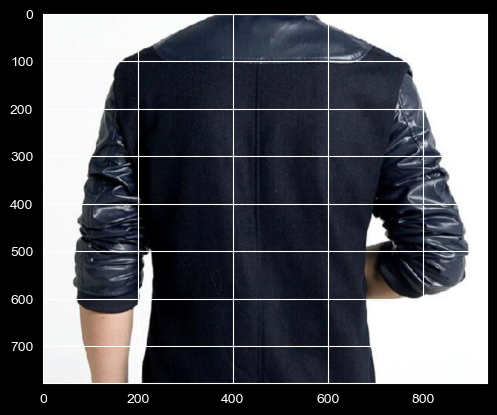

In [1]:
import os
from PIL import Image
from matplotlib import pyplot as plt

from perception_layer.clothing_detection_segmintation import model, inference

example_imgs = [Image.open(f"examples/{path}") for path in os.listdir("examples")]

model_path = "perception_layer/clothing_detection_segmintation/output/checkpoint_best_regular.pth"
garment_datector = inference.GarmentDetector(model_path)
outfits = {}

for img in example_imgs:
    garments = garment_datector.predict(img)
    print(f"Detected {len(garments)} garments in {img.filename}")
    for garment in garments:
        print(f"  {garment['category_name']} ({garment['confidence']:.2f})")
        plt.imshow(garment["image"])
    outfits[img.filename] = {"garments":garments}

outfits

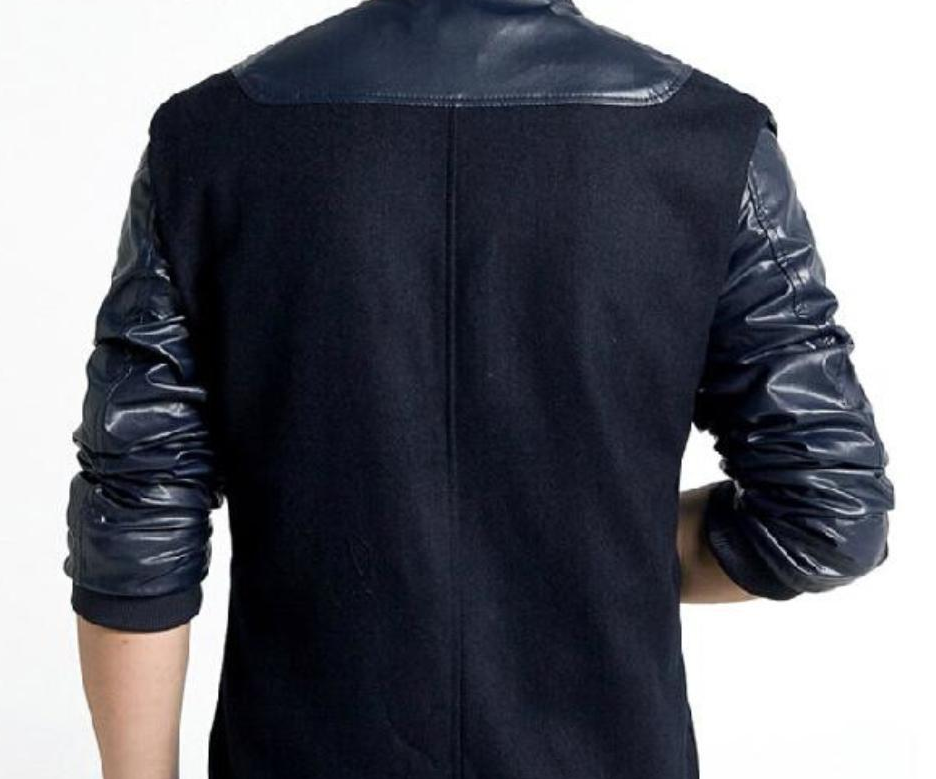

In [6]:
outfits[example_imgs[5].filename]["garments"][0]["image"]

In [7]:
example_imgs[5].filename

'examples/ex3.jpeg'

### B. Multi-Attribute Classifier (EfficientNet-B0, Multi-Head)

**Architecture:** Single backbone + multiple heads.
**Why:** Run one forward pass and predict multiple attributes (saves compute vs separate models).

**Predicted attributes (examples):**

* fit: slim / regular / oversized
* style: formal / casual / sporty
* weather_warmth: 0–1 (cold → warm)
* formality_score: 0–1

#### Input:

A normalized cropped item image, optionally with the garment type id.

#### Output:

Attribute probabilities + scalar metrics.

#### Example:

```txt
Input:
    torch.Tensor()  # Shape: (1, 3, 224, 224)

Output:
    {
        "fit": torch.Tensor([0.1, 0.8, 0.1]),            # -> "Regular"
        "style": torch.Tensor([0.05, 0.9, 0.05]),        # -> "Casual"
        "weather_warmth": 0.75,                          # 0.0 cold -> 1.0 warm
        "formality_score": 0.20                          # 0.0 PJs  -> 1.0 tux
    }
```
**Labeling strategy:**

* Cloud training can use **pseudo-labeling** via a vision-language model (CLIP-style) + a small manually verified set.

---

In [10]:
from perception_layer.multi_attribute_classifire import inference
model_path = "perception_layer/multi_attribute_classifire/runs/1b/best_model.pt"
multi_attribute_classifier = inference.AttributePredictor(model_path)
for img in example_imgs:
    for idx, garment in enumerate(outfits[img.filename]["garments"]):
        img_att = multi_attribute_classifier.predict(garment["image"].convert("RGB"))
        outfits[img.filename]["garments"][idx]["attributes"] = img_att
    print(outfits[img.filename])

{'garments': []}
{'garments': [{'category_id': 10, 'category_name': 'class_10', 'confidence': 0.5561310648918152, 'bbox': [-2.7558746337890625, 221.77357482910156, 556.870849609375, 633.8084716796875], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=560x412 at 0x1683A88F0>, 'attributes': {'fit': [0.338456392288208, 0.3360210359096527, 0.3255225419998169], 'style': [0.2523899972438812, 0.24939142167568207, 0.24894212186336517, 0.24927647411823273], 'weather_warmth': 0.5236966013908386, 'formality_score': 0.4989914894104004, 'fit_label': 'slim', 'style_label': 'formal'}}]}
{'garments': []}
{'garments': []}
{'garments': [{'category_id': 31, 'category_name': 'class_31', 'confidence': 0.7324281334877014, 'bbox': [166.36962890625, 196.75137329101562, 875.9052734375, 333.8730163574219], 'mask': None, 'image': <PIL.Image.Image image mode=RGB size=710x137 at 0x33E5A8230>, 'attributes': {'fit': [0.3343825042247772, 0.33515018224716187, 0.3304673433303833], 'style': [0.250977545976638

In [12]:
outfits

{'examples/ex1.jpeg': {'garments': []},
 'examples/ex4.jpeg': {'garments': [{'category_id': 10,
    'category_name': 'class_10',
    'confidence': 0.5561310648918152,
    'bbox': [-2.7558746337890625,
     221.77357482910156,
     556.870849609375,
     633.8084716796875],
    'mask': None,
    'image': <PIL.Image.Image image mode=RGB size=560x412>,
    'attributes': {'fit': [0.338456392288208,
      0.3360210359096527,
      0.3255225419998169],
     'style': [0.2523899972438812,
      0.24939142167568207,
      0.24894212186336517,
      0.24927647411823273],
     'weather_warmth': 0.5236966013908386,
     'formality_score': 0.4989914894104004,
     'fit_label': 'slim',
     'style_label': 'formal'}}]},
 'examples/ex5.jpeg': {'garments': []},
 'examples/ex6.jpg': {'garments': []},
 'examples/ex2.jpeg': {'garments': [{'category_id': 31,
    'category_name': 'class_31',
    'confidence': 0.7324281334877014,
    'bbox': [166.36962890625,
     196.75137329101562,
     875.9052734375,
   

In [14]:
outfits[example_imgs[5].filename]["garments"][0]["attributes"]

{'fit': [0.3349230885505676, 0.33709412813186646, 0.3279828131198883],
 'style': [0.25061890482902527,
  0.24868495762348175,
  0.24944856762886047,
  0.2512475848197937],
 'weather_warmth': 0.5128064751625061,
 'formality_score': 0.49862679839134216,
 'fit_label': 'regular',
 'style_label': 'streetwear'}

### E. Color Harmony Score (Function)

#### Input:

Cropped clothing item images and the number of dominant colors per garment.

#### Output:

Color harmony score between 0 and 1 of the cropped images combined

#### Example:
```txt
Input:
    images : list[PIL.Image, PIL.Image, PIL.Image] # 3 images
    k : 5 # number of dominant colors per garment

Output:
    0.75 #  The color harmony score is 75%
```

In [ ]:
from perception_layer import color_utils
for img in example_imgs:
    outfit_cropped_imgs = [garment["image"].convert("RGB") for garment in outfits[img.filename]["garments"]]
    outfits[img.filename]["color_harmony"] = color_utils.harmony_score_from_images(outfit_cropped_imgs)
    print(outfits[img.filename])

{'garments': [], 'color_harmony': 0.0}


## 2. Textual Query Understanding (Semantic Processing)

This layer transforms a user request (text) into intent signals and an embedding usable by ranking.

### A. Query Vectorization (Mobile Text Encoder)

**Model:** Distilled BERT / MobileCLIP text branch.
**Purpose:** Encode user query into a 512-dim vector aligned with image vectors.

#### Input:

A user query string.

#### Output:

A 512-dim embedding vector.

#### Example:

```txt
Input:
    "business meeting, looking for comfort"

Output:
    torch.Tensor()  # Shape: (1, 512)
```

In [ ]:
from semantic_processing.ranking_utils import garment_score
from semantic_processing.query_vectorization.query_vectorizer import QueryVectorizer, query_vec

usr_input_sentence = "I have a business meeting, looking for comfort"
sentence_transformer = QueryVectorizer(model_path="semantic_processing/query_vectorization/distilled_query_encoder.pth")
query_vec = sentence_transformer.encode(usr_input_sentence)

filters = {
    "min_formality": 0.4,
    "max_warmth": 0.7,
    "sporty_ok": False
}

context = {
    "temperature": 20
}
for filename, data in outfits.items():
    for garment in data["garments"]:
        score = garment_score(
            garment,
            query_vec,
            filters,
            context
        )

        garment["match_score"] = round(score, 3)

    print(filename, data["garments"])

## 3. Representation Layer (Vectorization)

This layer produces vectors for fast similarity search and outfit relevance.

### A. Visual Embeddings (Student CLIP)

**Model:** MobileNetV3 image encoder distilled from CLIP (ViT teacher).
**Purpose:** Convert each item image into a normalized 512-dim “vibe” embedding.

#### Input:

Cropped image tensor.

#### Output:

Normalized embedding.

#### Example:

```txt
Input:
    torch.Tensor()  # (1, 3, 224, 224)

Output:
    torch.Tensor()  # (1, 512)
```

---

### B. Text Embeddings

**Purpose:** Ensure text and image vectors live in the same embedding space (512-dim).

---

### C. Local Vector Store

**Storage:** SQLite + local files, or a compact ANN index.
**Purpose:** Nearest-neighbor retrieval without internet.

#### Example:

```txt
Stored:
    item_id -> embedding(512) + metadata
Search:
    top_k by cosine similarity
```

---